# 🚧 PRF 2025 — Análise de Acidentes com Pandas e Matplotlib

Este notebook adapta os **mesmos tipos de gráficos e a mesma lógica visual** do arquivo de referência `graficos12.ipynb` para o projeto de acidentes da PRF em 2025.

O objetivo é usar a base real do projeto para praticar **Pandas, NumPy e Matplotlib**, mantendo os gráficos do código fornecido: histograma, densidade, dispersão, regressão, boxplot, barras, setores, heatmaps, gráfico 3D, linha, Pareto, área e radar.

> **Nota acadêmica:** a atividade original orienta que a entrega oficial seja construída no Excel/Google Sheets. Este notebook é uma **extensão paralela de estudo e portfólio em Python**, sem substituir a entrega exigida pelo professor.

## 1. Importação das bibliotecas

As bibliotecas abaixo seguem a estrutura do código original. O `Pandas` será responsável pela leitura e transformação dos dados; o `NumPy` por cálculos numéricos; e o `Matplotlib` pelos gráficos. O `Seaborn` permanece importado para manter compatibilidade com o material de referência, embora os gráficos principais sejam construídos com Matplotlib/Pandas.

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Exibe os gráficos dentro do notebook
%matplotlib inline

# Configuração geral apenas para melhorar a leitura dos gráficos
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Leitura da base do projeto

A base usada é o Excel trabalhado no projeto PRF 2025. A aba principal contém os registros individuais de acidentes e também as colunas auxiliares construídas durante a atividade.

In [2]:
# Caminhos do projeto
PASTA_PROJETO = Path("..") if Path.cwd().name == "notebooks" else Path(".")
ARQUIVO = PASTA_PROJETO / "dados" / "dados_abertos_prf_2025.xlsx"
PASTA_GRAFICOS = PASTA_PROJETO / "graficos"
PASTA_GRAFICOS.mkdir(exist_ok=True)

# Nome exato da aba da base no Excel
ABA_DADOS = "dados_abertos_prf-datatran2025 "

# Leitura da planilha
# openpyxl é o mecanismo usado pelo Pandas para arquivos .xlsx
df = pd.read_excel(ARQUIVO, sheet_name=ABA_DADOS, engine="openpyxl")

print("Arquivo carregado:", ARQUIVO)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
df.head()

Arquivo carregado: ..\dados\dados_abertos_prf_2025.xlsx
Linhas: 72529
Colunas: 32


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,Total_de_vitimas,Acidentes_Fatais
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225.0,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,...,1,1,2,-23.485868,-46.540753,SPRF-SP,DEL01-SP,UOP01-DEL01-SP,1,0
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,546.2,PENAFORTE,Pista esburacada,Colisão frontal,...,4,1,6,-7.812288,-39.083333,SPRF-CE,DEL05-CE,UOP03-DEL05-CE,2,1
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,88.2,CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,...,0,3,2,-23.182565,-50.637228,SPRF-PR,DEL07-PR,UOP05-DEL07-PR,3,0
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,0,1,2,-25.365177,-49.042230,SPRF-PR,DEL01-PR,UOP02-DEL01-PR,1,0
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471.0,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,...,2,2,4,-16.468013,-43.431213,SPRF-MG,DEL12-MG,UOP01-DEL12-MG,2,0


## 3. Preparação e validação dos dados

O código original cria uma variável binária chamada `acidente_fatal`. No nosso projeto, a planilha já possui `Acidentes_Fatais`, mas vamos recriar a coluna com a mesma lógica do código fornecido: **1 quando `mortos > 0` e 0 caso contrário**.

Também serão criadas colunas auxiliares de data, mês e hora para os gráficos temporais.

In [3]:
# Mantém a lógica do código original: 1 = acidente fatal; 0 = não fatal
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)

# Validação: a coluna criada deve coincidir com a coluna auxiliar já existente no projeto
if "Acidentes_Fatais" in df.columns:
    divergencias = (df["acidente_fatal"] != df["Acidentes_Fatais"]).sum()
    print("Divergências entre as duas colunas de acidente fatal:", divergencias)

# Subconjunto somente com acidentes fatais
fatal = df[df["acidente_fatal"] == 1].copy()

# Conversão e criação de variáveis temporais
df["data"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["mes"] = df["data"].dt.month

# A coluna horario vem do Excel como objeto datetime.time.
# Esta função extrai somente a hora de maneira segura.
def extrair_hora(valor):
    if pd.isna(valor):
        return np.nan
    if hasattr(valor, "hour"):
        return valor.hour
    convertido = pd.to_datetime(str(valor), format="%H:%M:%S", errors="coerce")
    return convertido.hour if not pd.isna(convertido) else np.nan

df["hora_num"] = df["horario"].apply(extrair_hora)

# Nomes dos meses para melhorar os eixos dos gráficos
nomes_meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

print("Total de acidentes fatais:", fatal.shape[0])

Divergências entre as duas colunas de acidente fatal: 0
Total de acidentes fatais: 5210


## 4. Indicadores globais do projeto

Antes dos gráficos, validamos os principais números usados na análise. Isso ajuda a garantir que o Pandas está trabalhando com a mesma base consolidada no Excel.

In [4]:
# Cálculo dos KPIs globais
kpi_total_acidentes = df["id"].count()
kpi_total_mortos = df["mortos"].sum()
kpi_total_feridos = df["feridos_leves"].sum() + df["feridos_graves"].sum()
kpi_total_vitimas = df["Total_de_vitimas"].sum()
kpi_acidentes_fatais = df["acidente_fatal"].sum()
kpi_percentual_fatais = kpi_acidentes_fatais / kpi_total_acidentes * 100
kpi_letalidade = kpi_total_mortos / kpi_total_vitimas * 100

print(f"Total de acidentes: {kpi_total_acidentes:,}".replace(",", "."))
print(f"Total de mortos: {kpi_total_mortos:,}".replace(",", "."))
print(f"Total de feridos: {kpi_total_feridos:,}".replace(",", "."))
print(f"Total de vítimas: {kpi_total_vitimas:,}".replace(",", "."))
print(f"Acidentes fatais: {kpi_acidentes_fatais:,}".replace(",", "."))
print(f"% de acidentes fatais: {kpi_percentual_fatais:.2f}%")
print(f"Taxa de letalidade operacional: {kpi_letalidade:.2f}%")

Total de acidentes: 72.529
Total de mortos: 6.043
Total de feridos: 83.550
Total de vítimas: 89.593
Acidentes fatais: 5.210
% de acidentes fatais: 7.18%
Taxa de letalidade operacional: 6.74%


# 📊 Gráfico 1 — Histograma de mortos por acidente fatal

**Mesmo tipo de gráfico do código original:** `plt.hist()`.

### O que ele mostra
O histograma apresenta a distribuição da quantidade de mortos **dentro dos acidentes que tiveram pelo menos um óbito**. Ele ajuda a perceber se os acidentes fatais normalmente concentram uma morte ou se há grande frequência de eventos com múltiplas mortes.

,mortos,quantidade_acidentes,percentual
0,1,4632,88.9
1,2,434,8.3
2,3,93,1.8
3,4,28,0.5
4,5,13,0.2
5,6,3,0.1
6,7,2,0.0
7,9,2,0.0
8,10,1,0.0
9,11,1,0.0


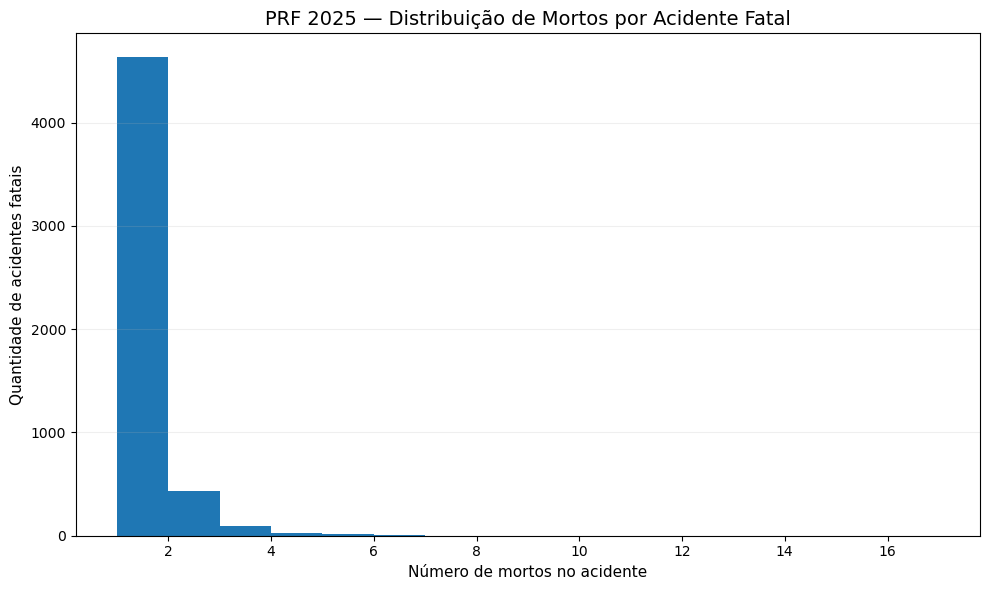

📌 Leitura: 4632 dos 5210 acidentes fatais tiveram exatamente 1 morte (88.9%).


In [5]:
# Tabela auxiliar: quantidade de acidentes para cada número de mortos
tabela = fatal["mortos"].value_counts().sort_index().reset_index()
tabela.columns = ["mortos", "quantidade_acidentes"]
tabela["percentual"] = (
    tabela["quantidade_acidentes"] / tabela["quantidade_acidentes"].sum() * 100
).round(1)

display(tabela)

# Histograma - mesma estrutura do código original
plt.figure(figsize=(10, 6))
plt.hist(fatal["mortos"], bins=range(1, fatal["mortos"].max() + 2))
plt.title("PRF 2025 — Distribuição de Mortos por Acidente Fatal")
plt.xlabel("Número de mortos no acidente")
plt.ylabel("Quantidade de acidentes fatais")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "01_histograma_mortos.png", dpi=180, bbox_inches="tight")
plt.show()

um_morto = tabela.loc[tabela["mortos"] == 1, "quantidade_acidentes"].iloc[0]
print(f"📌 Leitura: {um_morto} dos {len(fatal)} acidentes fatais tiveram exatamente 1 morte ({um_morto/len(fatal)*100:.1f}%).")

# 📈 Gráfico 2 — Densidade de pessoas: acidentes fatais x não fatais

**Mesmo tipo de gráfico do código original:** `Series.plot(kind="density")`.

### O que ele mostra
Compara a distribuição do número de pessoas envolvidas nos acidentes fatais e não fatais. Para impedir que poucos acidentes extremos distorçam a visualização, mantemos o limite superior de 15 pessoas, exatamente como na lógica do material fornecido.

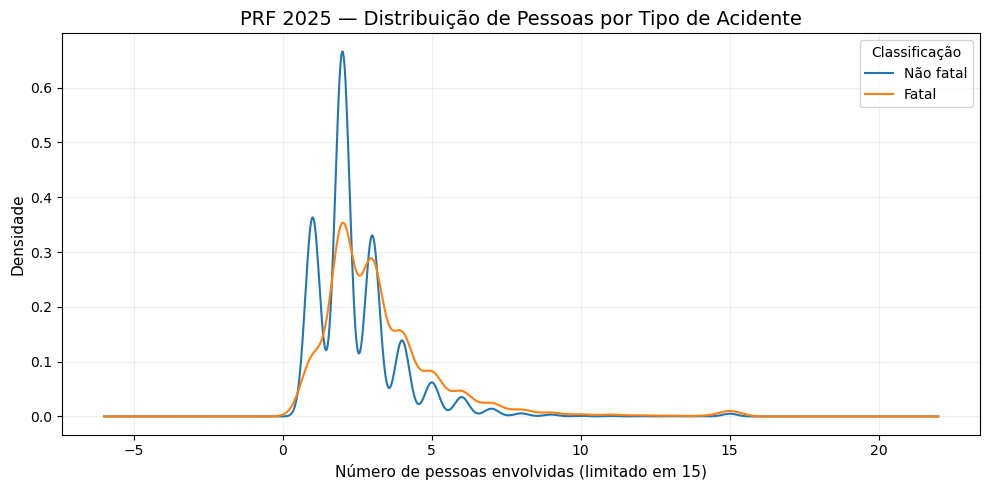

📌 Leitura: acidentes não fatais têm média de 2.53 pessoas; acidentes fatais, 3.46 pessoas.


In [6]:
# Gráfico de densidade
plt.figure(figsize=(10, 5))

for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    dados = df.loc[df["acidente_fatal"] == classe, "pessoas"].dropna().clip(upper=15)

    # Para o cálculo de densidade ficar rápido no VS Code, usamos no máximo
    # 10.000 observações por classe. O tipo de gráfico e a interpretação permanecem iguais.
    if len(dados) > 10000:
        dados = dados.sample(10000, random_state=42)

    dados.plot(kind="density", label=nome)

plt.title("PRF 2025 — Distribuição de Pessoas por Tipo de Acidente")
plt.xlabel("Número de pessoas envolvidas (limitado em 15)")
plt.ylabel("Densidade")
plt.legend(title="Classificação")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "02_densidade_pessoas.png", dpi=180, bbox_inches="tight")
plt.show()

media_nao_fatal = df.loc[df["acidente_fatal"] == 0, "pessoas"].mean()
media_fatal = df.loc[df["acidente_fatal"] == 1, "pessoas"].mean()
print(f"📌 Leitura: acidentes não fatais têm média de {media_nao_fatal:.2f} pessoas; acidentes fatais, {media_fatal:.2f} pessoas.")

# 🔹 Gráfico 3 — Dispersão entre veículos e pessoas

**Mesmo tipo de gráfico do código original:** `plt.scatter()`.

### O que ele mostra
Cada ponto representa um acidente da amostra. O eixo X mostra o número de veículos e o eixo Y o número de pessoas envolvidas. O objetivo é observar visualmente se acidentes com mais veículos também tendem a envolver mais pessoas.

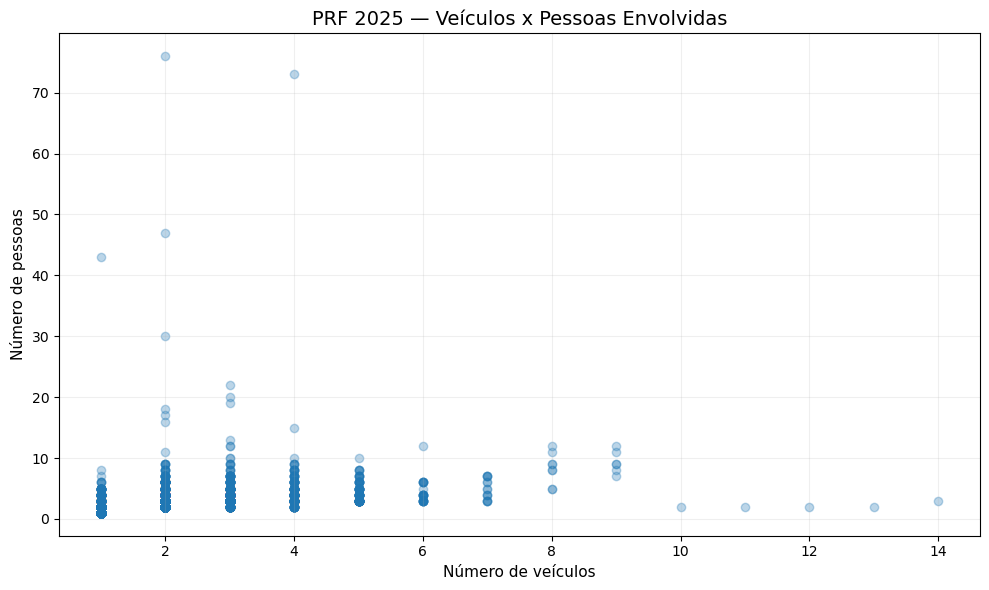

📌 Leitura: a correlação linear entre veículos e pessoas é 0.395. Existe associação positiva, mas ela não implica causalidade.


In [7]:
# Amostra de 5.000 registros para manter o gráfico legível
amostra = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)
plt.title("PRF 2025 — Veículos x Pessoas Envolvidas")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "03_dispersao_veiculos_pessoas.png", dpi=180, bbox_inches="tight")
plt.show()

correlacao = df[["veiculos", "pessoas"]].corr().iloc[0, 1]
print(f"📌 Leitura: a correlação linear entre veículos e pessoas é {correlacao:.3f}. Existe associação positiva, mas ela não implica causalidade.")

# 📐 Gráfico 4 — Dispersão com linha de tendência

**Mesmo gráfico adicional do código original:** dispersão com uma reta obtida por `np.polyfit()`.

### O que ele mostra
Mantém os mesmos pontos do gráfico anterior e acrescenta uma linha de tendência linear. A linha resume a direção média da relação entre quantidade de veículos e pessoas envolvidas.

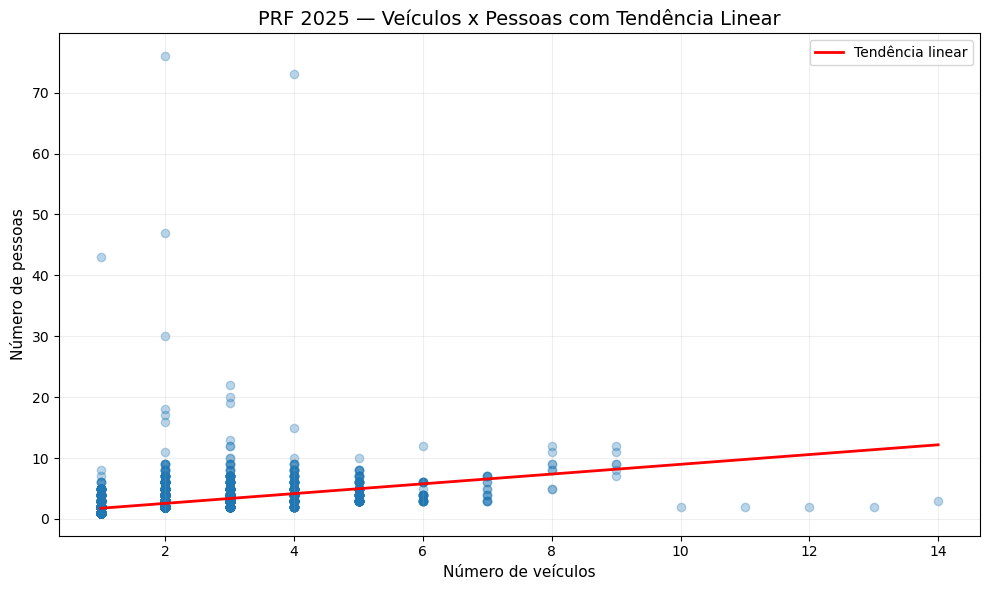

📌 Leitura: na amostra, a inclinação da reta é 0.80. A linha resume associação média e não deve ser interpretada como efeito causal.


In [9]:
# Mesma amostra e mesma lógica do código fornecido
amostra = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)

# Ajuste de uma reta: y = b0 + b1*x
b1, b0 = np.polyfit(amostra["veiculos"], amostra["pessoas"], 1)
x_linha = np.linspace(amostra["veiculos"].min(), amostra["veiculos"].max(), 100)
plt.plot(x_linha, b0 + b1 * x_linha, color="red", linewidth=2, label="Tendência linear")

plt.title("PRF 2025 — Veículos x Pessoas com Tendência Linear")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "04_dispersao_regressao.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"📌 Leitura: na amostra, a inclinação da reta é {b1:.2f}. A linha resume associação média e não deve ser interpretada como efeito causal.")

# 🟢 Gráfico 5 — Dispersão com legenda de fatalidade

**Mesmo tipo do código original:** dois grupos desenhados com `plt.scatter()` e legenda.

### O que ele mostra
Separa os acidentes em **fatais** e **não fatais** dentro do espaço veículos × pessoas. Isso permite verificar se os acidentes fatais aparecem apenas em valores extremos ou também em regiões comuns do conjunto de dados.

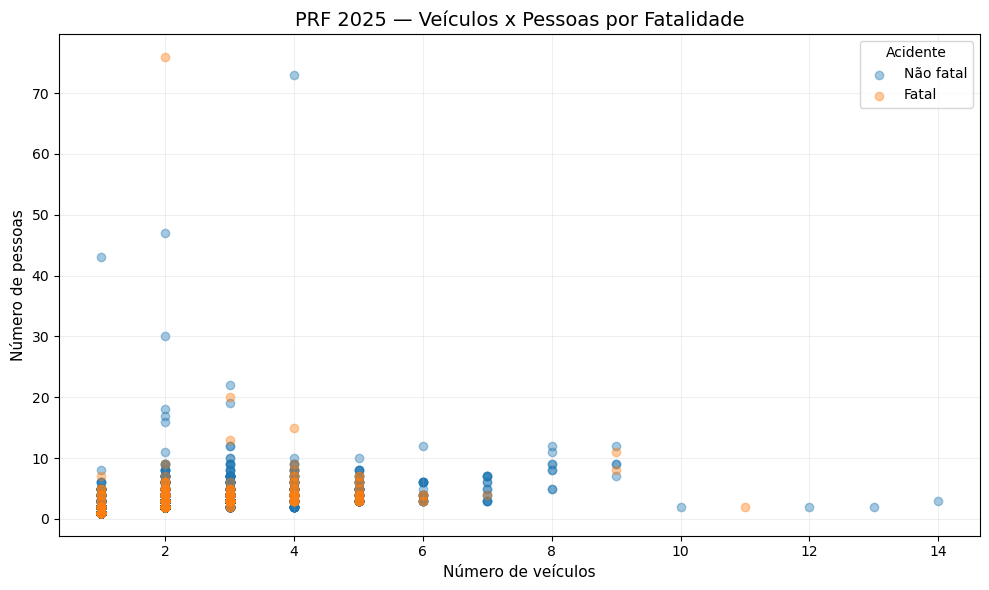

📌 Leitura: os dois grupos se sobrepõem em grande parte. Portanto, veículos e pessoas isoladamente não explicam a fatalidade do acidente.


In [10]:
# Dispersão com legendas
amostra = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))

for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    grupo = amostra[amostra["acidente_fatal"] == classe]
    plt.scatter(grupo["veiculos"], grupo["pessoas"], alpha=0.4, label=nome)

plt.title("PRF 2025 — Veículos x Pessoas por Fatalidade")
plt.xlabel("Número de veículos")
plt.ylabel("Número de pessoas")
plt.legend(title="Acidente")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "05_dispersao_fatalidade.png", dpi=180, bbox_inches="tight")
plt.show()

print("📌 Leitura: os dois grupos se sobrepõem em grande parte. Portanto, veículos e pessoas isoladamente não explicam a fatalidade do acidente.")

# 📅 Gráfico 6 — Evolução mensal: quantidade e percentual de acidentes fatais

**Mesmo formato do código original:** figura dividida em **dois gráficos lado a lado** com `plt.subplots(1, 2)`.

### O que ele mostra
O painel esquerdo apresenta a quantidade mensal de acidentes fatais. O painel direito mostra o percentual de acidentes fatais em relação ao total de acidentes de cada mês. Isso evita confundir **volume absoluto** com **risco proporcional**.

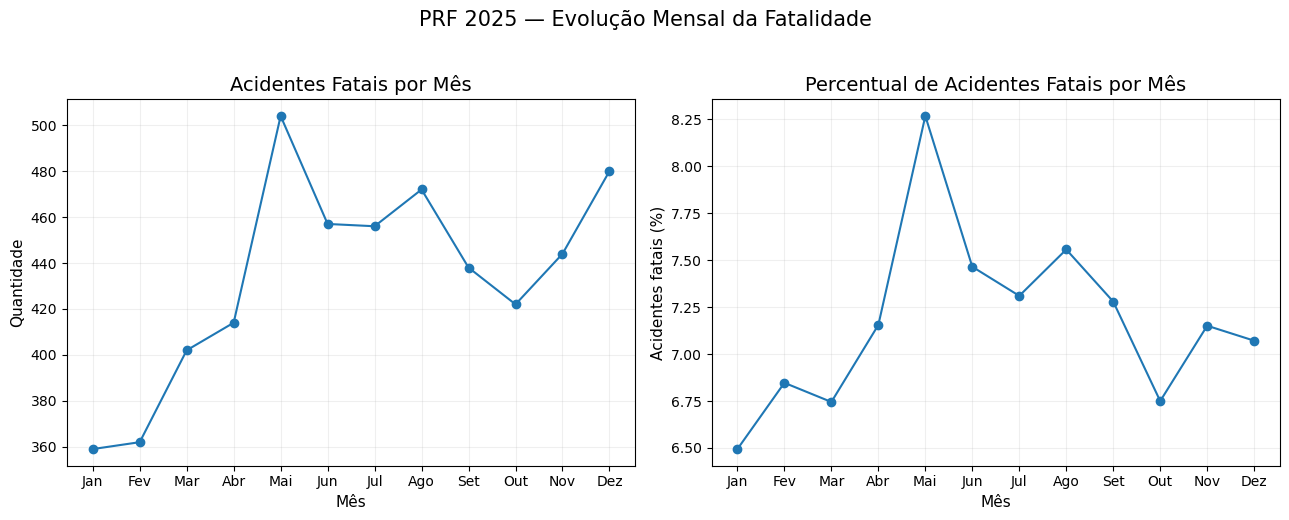

📌 Leitura: Mai teve o maior número de acidentes fatais (504) e também o maior percentual mensal (8.27%).


In [11]:
# Agregação mensal
m = df.groupby("mes").agg(
    acidentes=("id", "count"),
    fatais=("acidente_fatal", "sum")
)
m["taxa"] = m["fatais"] / m["acidentes"] * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: quantidade de fatais
ax[0].plot(m.index, m["fatais"], marker="o")
ax[0].set_title("Acidentes Fatais por Mês")
ax[0].set_xlabel("Mês")
ax[0].set_ylabel("Quantidade")
ax[0].set_xticks(range(1, 13), [nomes_meses[i] for i in range(1, 13)])
ax[0].grid(alpha=0.2)

# Painel 2: percentual de fatais
ax[1].plot(m.index, m["taxa"], marker="o")
ax[1].set_title("Percentual de Acidentes Fatais por Mês")
ax[1].set_xlabel("Mês")
ax[1].set_ylabel("Acidentes fatais (%)")
ax[1].set_xticks(range(1, 13), [nomes_meses[i] for i in range(1, 13)])
ax[1].grid(alpha=0.2)

fig.suptitle("PRF 2025 — Evolução Mensal da Fatalidade", y=1.03, fontsize=15)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "06_evolucao_mensal_duplo.png", dpi=180, bbox_inches="tight")
plt.show()

mes_max = m["fatais"].idxmax()
mes_taxa = m["taxa"].idxmax()
print(f"📌 Leitura: {nomes_meses[mes_max]} teve o maior número de acidentes fatais ({m.loc[mes_max, 'fatais']}) e também o maior percentual mensal ({m.loc[mes_taxa, 'taxa']:.2f}%).")

# 📦 Gráfico 7 — Boxplot de pessoas por fatalidade

**Mesmo tipo de gráfico do código original:** `plt.boxplot()`.

### O que ele mostra
Compara a distribuição de pessoas envolvidas nos acidentes não fatais e fatais. Os outliers ficam ocultos (`showfliers=False`), seguindo o código fornecido, para destacar mediana e dispersão central.

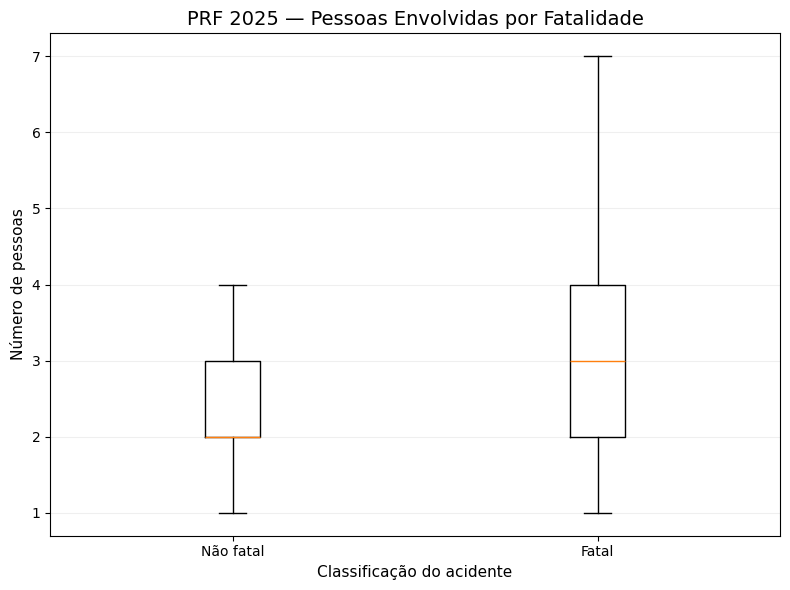

📌 Leitura: a mediana é 2 pessoas nos acidentes não fatais e 3 nos fatais.


In [12]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [
        df.loc[df["acidente_fatal"] == 0, "pessoas"],
        df.loc[df["acidente_fatal"] == 1, "pessoas"]
    ],
    tick_labels=["Não fatal", "Fatal"],
    showfliers=False
)

plt.title("PRF 2025 — Pessoas Envolvidas por Fatalidade")
plt.xlabel("Classificação do acidente")
plt.ylabel("Número de pessoas")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "07_boxplot_pessoas.png", dpi=180, bbox_inches="tight")
plt.show()

mediana_nao_fatal = df.loc[df["acidente_fatal"] == 0, "pessoas"].median()
mediana_fatal = df.loc[df["acidente_fatal"] == 1, "pessoas"].median()
print(f"📌 Leitura: a mediana é {mediana_nao_fatal:.0f} pessoas nos acidentes não fatais e {mediana_fatal:.0f} nos fatais.")

# 🗺️ Gráfico 8 — Top 10 UFs por acidentes fatais

**Mesmo tipo de gráfico do código original:** barras horizontais com `plt.barh()`.

### O que ele mostra
Ordena as dez unidades federativas com maior **quantidade absoluta de acidentes fatais**. Este gráfico mede volume e não a taxa de letalidade.

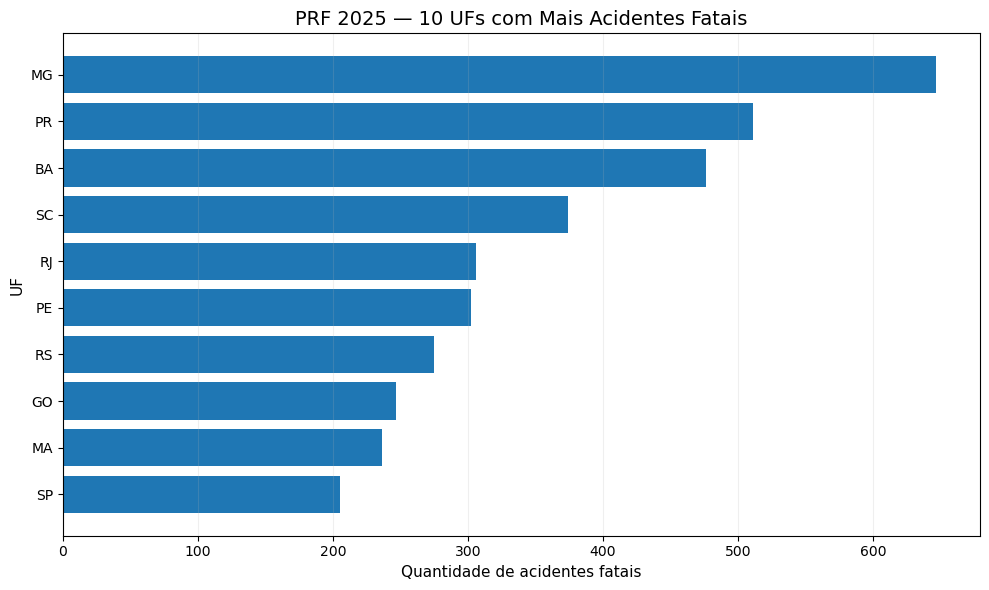

📌 Leitura: MG apresenta o maior volume de acidentes fatais, com 647 ocorrências.


In [13]:
# Soma dos acidentes fatais por UF
uf = df.groupby("uf")["acidente_fatal"].sum().nlargest(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(uf.index, uf.values)
plt.title("PRF 2025 — 10 UFs com Mais Acidentes Fatais")
plt.xlabel("Quantidade de acidentes fatais")
plt.ylabel("UF")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "08_top10_uf_fatais.png", dpi=180, bbox_inches="tight")
plt.show()

lider = uf.idxmax()
print(f"📌 Leitura: {lider} apresenta o maior volume de acidentes fatais, com {int(uf.max())} ocorrências.")

# 🥧 Gráfico 9 — Distribuição dos acidentes fatais por fase do dia

**Mesmo tipo de gráfico do código original:** gráfico de setores com `plt.pie()`.

### O que ele mostra
Mostra como os 5.210 acidentes fatais se distribuem entre as fases do dia. Este gráfico apresenta **participação no total de fatais**, e não o percentual de fatalidade dentro de cada fase.

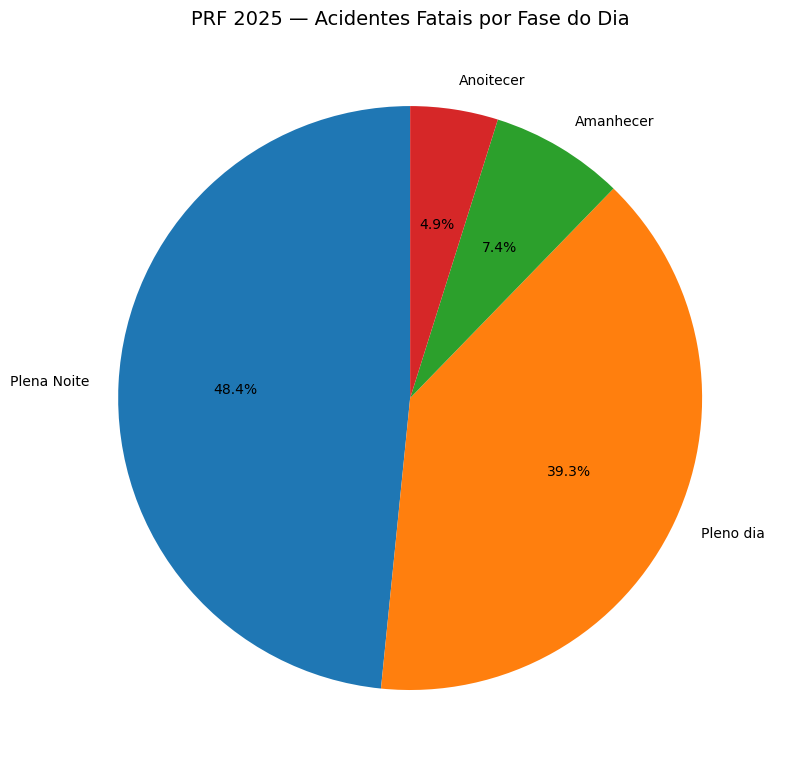

📌 Leitura: Plena Noite concentra 2522 acidentes fatais, equivalentes a 48.4% do total de acidentes fatais.


In [14]:
# Seleciona somente acidentes fatais e conta por fase do dia
fatal = df[df["acidente_fatal"] == 1]
p = fatal["fase_dia"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(p.values, labels=p.index, autopct="%1.1f%%", startangle=90)
plt.title("PRF 2025 — Acidentes Fatais por Fase do Dia")
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "09_pizza_fase_dia.png", dpi=180, bbox_inches="tight")
plt.show()

principal = p.idxmax()
print(f"📌 Leitura: {principal} concentra {p.max()} acidentes fatais, equivalentes a {p.max()/p.sum()*100:.1f}% do total de acidentes fatais.")

# 🔥 Gráfico 10 — Heatmap de acidentes fatais por dia da semana e hora

**Mesmo tipo de gráfico do código original:** matriz com `plt.imshow()` e `plt.colorbar()`.

### O que ele mostra
Cruza **dia da semana × hora do dia**, somando acidentes fatais em cada combinação. Regiões mais intensas da matriz representam horários com maior quantidade de acidentes fatais.

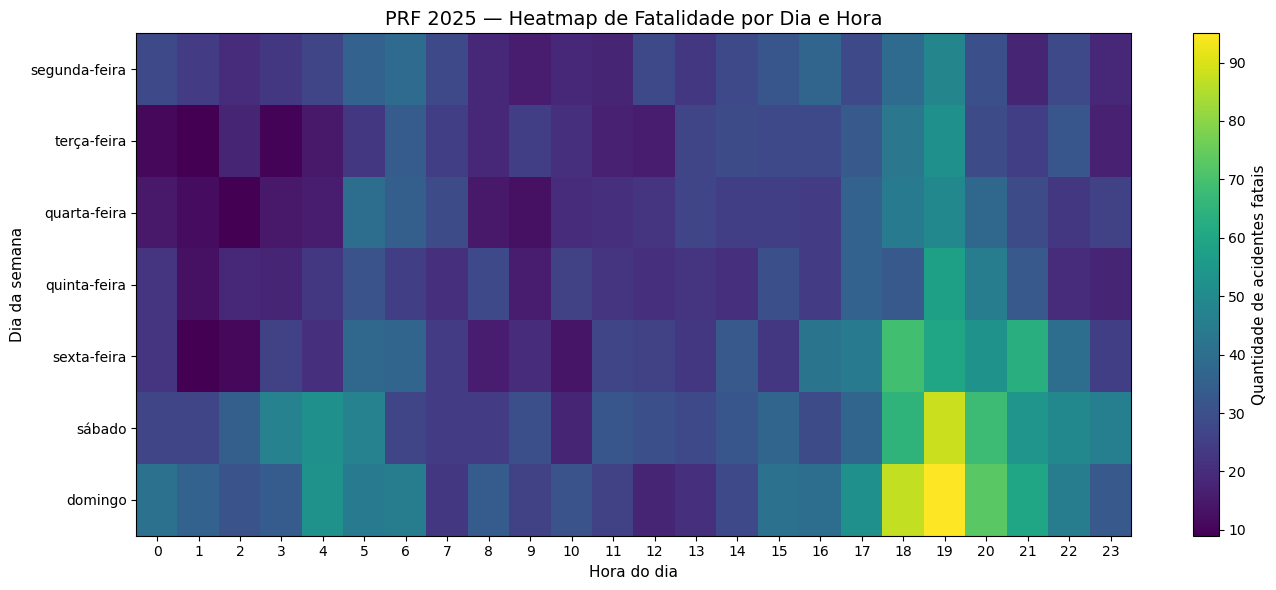

📌 Leitura: a maior célula da matriz é domingo, às 19h, com 95 acidentes fatais no ano.


In [15]:
# Ordem cronológica dos dias para melhorar a leitura
ordem_dias = [
    "segunda-feira", "terça-feira", "quarta-feira", "quinta-feira",
    "sexta-feira", "sábado", "domingo"
]

heat = pd.pivot_table(
    df,
    index="dia_semana",
    columns="hora_num",
    values="acidente_fatal",
    aggfunc="sum",
    fill_value=0
).reindex(ordem_dias)

plt.figure(figsize=(14, 6))
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="Quantidade de acidentes fatais")
plt.title("PRF 2025 — Heatmap de Fatalidade por Dia e Hora")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.xticks(range(len(heat.columns)), heat.columns.astype(int))
plt.yticks(range(len(heat.index)), heat.index)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "10_heatmap_dia_hora.png", dpi=180, bbox_inches="tight")
plt.show()

posicao_max = np.unravel_index(np.argmax(heat.values), heat.shape)
dia_max = heat.index[posicao_max[0]]
hora_max = int(heat.columns[posicao_max[1]])
valor_max = int(heat.values[posicao_max])
print(f"📌 Leitura: a maior célula da matriz é {dia_max}, às {hora_max}h, com {valor_max} acidentes fatais no ano.")

# 🧩 Gráfico 11 — Heatmap de correlação entre variáveis numéricas

**Mesmo tipo adicional do código original:** matriz de correlação com `df.corr()` + `plt.imshow()`.

### O que ele mostra
Resume associações lineares entre fatalidade, pessoas, feridos, ilesos, ignorados e veículos. Valores próximos de 1 indicam associação positiva; próximos de -1, associação negativa; próximos de 0, pouca associação linear.

> Correlação não significa causalidade.

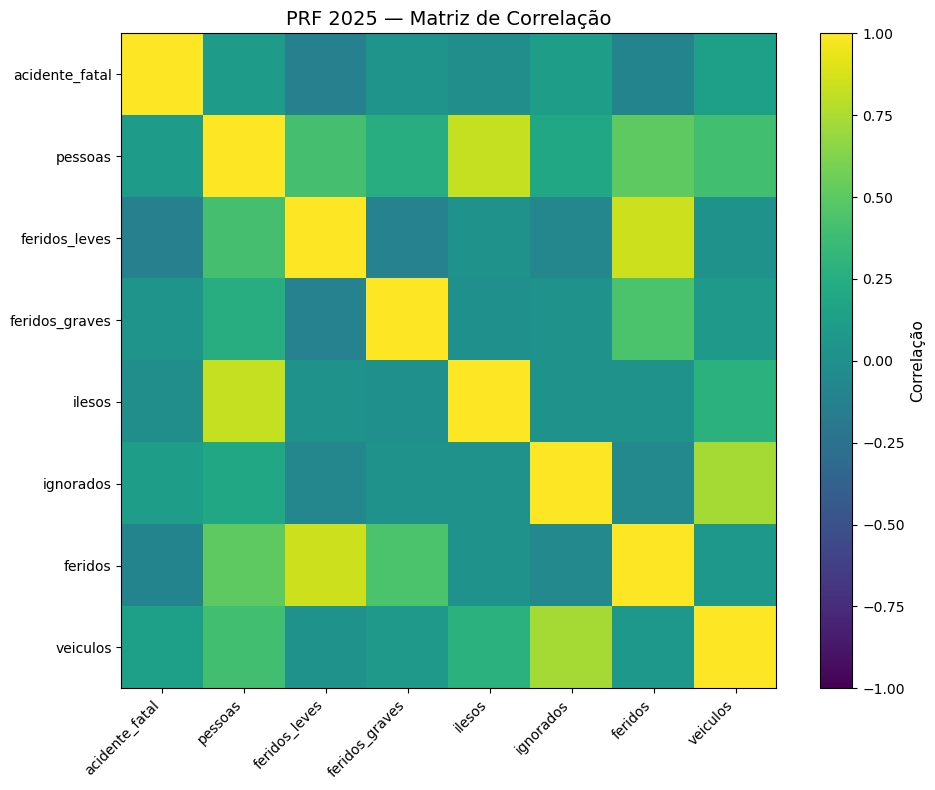

📌 Correlações com acidente_fatal:


,correlacao
feridos_leves,-0.129362
veiculos,0.125639
ignorados,0.117729
pessoas,0.106420
feridos,-0.100175
feridos_graves,0.032154
ilesos,-0.009246


In [16]:
cols = [
    "acidente_fatal", "pessoas", "feridos_leves", "feridos_graves",
    "ilesos", "ignorados", "feridos", "veiculos"
]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, vmin=-1, vmax=1)
plt.colorbar(label="Correlação")
plt.title("PRF 2025 — Matriz de Correlação")
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "11_heatmap_correlacao.png", dpi=180, bbox_inches="tight")
plt.show()

corr_fatal = corr["acidente_fatal"].drop("acidente_fatal").sort_values(key=abs, ascending=False)
print("📌 Correlações com acidente_fatal:")
display(corr_fatal.to_frame("correlacao"))

# 🧊 Gráfico 12 — Dispersão 3D: veículos, pessoas e feridos graves

**Mesmo tipo de gráfico do código original:** `projection="3d"` com `ax.scatter()`.

### O que ele mostra
Cada ponto representa um acidente da amostra em três dimensões: veículos, pessoas e feridos graves. A cor é determinada por `acidente_fatal`, seguindo a mesma lógica do código original.

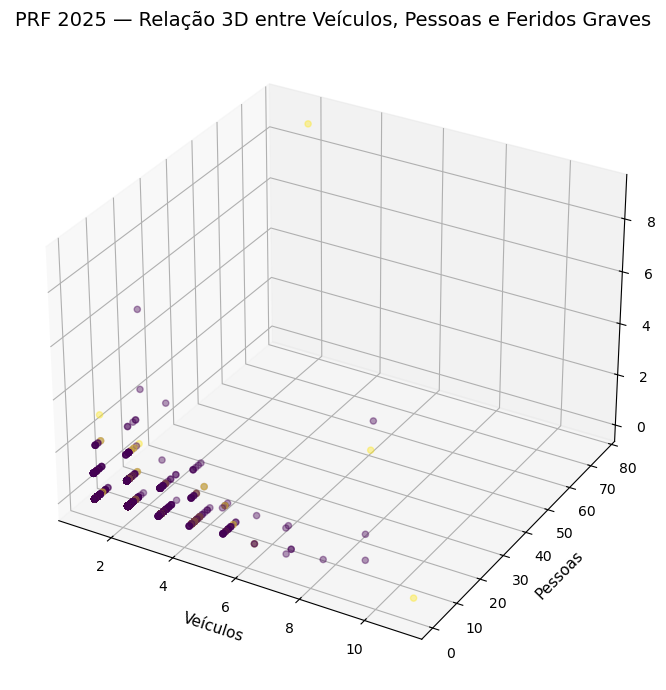

📌 Leitura: o gráfico 3D é exploratório. Ele ajuda a enxergar concentração e sobreposição, mas não deve ser usado sozinho para concluir causalidade ou risco.


In [17]:
# Amostra menor para não sobrecarregar a visualização 3D
s = df.sample(1500, random_state=42)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

pontos = ax.scatter(
    s["veiculos"],
    s["pessoas"],
    s["feridos_graves"],
    c=s["acidente_fatal"],
    alpha=0.4
)

ax.set_title("PRF 2025 — Relação 3D entre Veículos, Pessoas e Feridos Graves")
ax.set_xlabel("Veículos")
ax.set_ylabel("Pessoas")
ax.set_zlabel("Feridos graves")
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "12_dispersao_3d.png", dpi=180, bbox_inches="tight")
plt.show()

print("📌 Leitura: o gráfico 3D é exploratório. Ele ajuda a enxergar concentração e sobreposição, mas não deve ser usado sozinho para concluir causalidade ou risco.")

# 📉 Gráfico 13 — Linha mensal de acidentes fatais

**Mesmo tipo do código original:** `plt.plot()` com marcadores.

### O que ele mostra
Exibe apenas a quantidade de acidentes fatais ao longo dos 12 meses de 2025, facilitando a identificação de picos e quedas no ano.

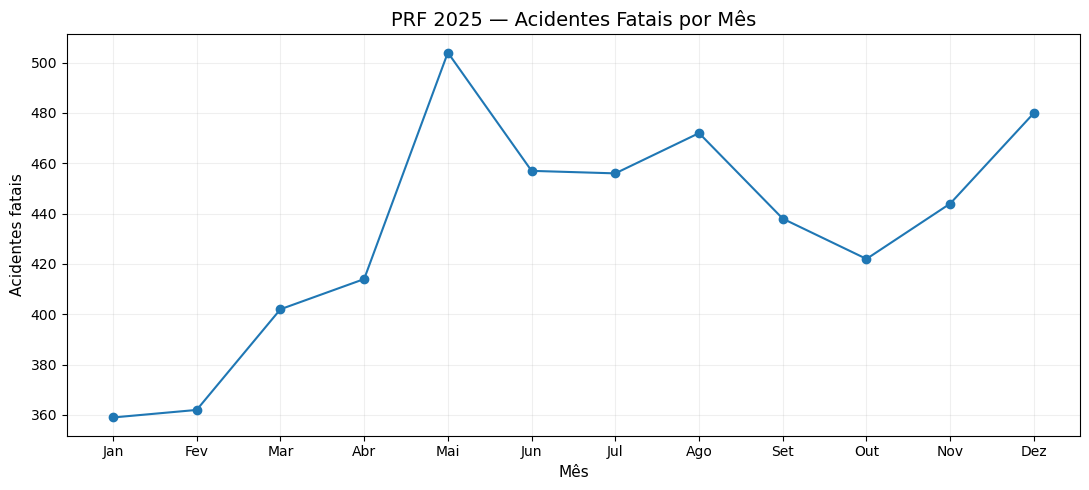

📌 Leitura: Mai foi o mês com maior número de acidentes fatais: 504.


In [18]:
# Soma mensal de acidentes fatais
mensal = df.groupby("mes")["acidente_fatal"].sum()

plt.figure(figsize=(11, 5))
plt.plot(mensal.index, mensal.values, marker="o")
plt.title("PRF 2025 — Acidentes Fatais por Mês")
plt.xlabel("Mês")
plt.ylabel("Acidentes fatais")
plt.xticks(range(1, 13), [nomes_meses[i] for i in range(1, 13)])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "13_linha_fatais_mes.png", dpi=180, bbox_inches="tight")
plt.show()

mes_pico = mensal.idxmax()
print(f"📌 Leitura: {nomes_meses[mes_pico]} foi o mês com maior número de acidentes fatais: {int(mensal.max())}.")

# 📊 Gráfico 14 — Pareto dos tipos de acidentes fatais

**Mesmo tipo de gráfico do código original:** barras + linha acumulada em eixo secundário (`twinx`) + referência de 80%.

### O que ele mostra
Ordena os tipos de acidente pela quantidade de ocorrências fatais e calcula o percentual acumulado. O princípio de Pareto ajuda a identificar quais tipos concentram a maior parcela dos acidentes fatais.

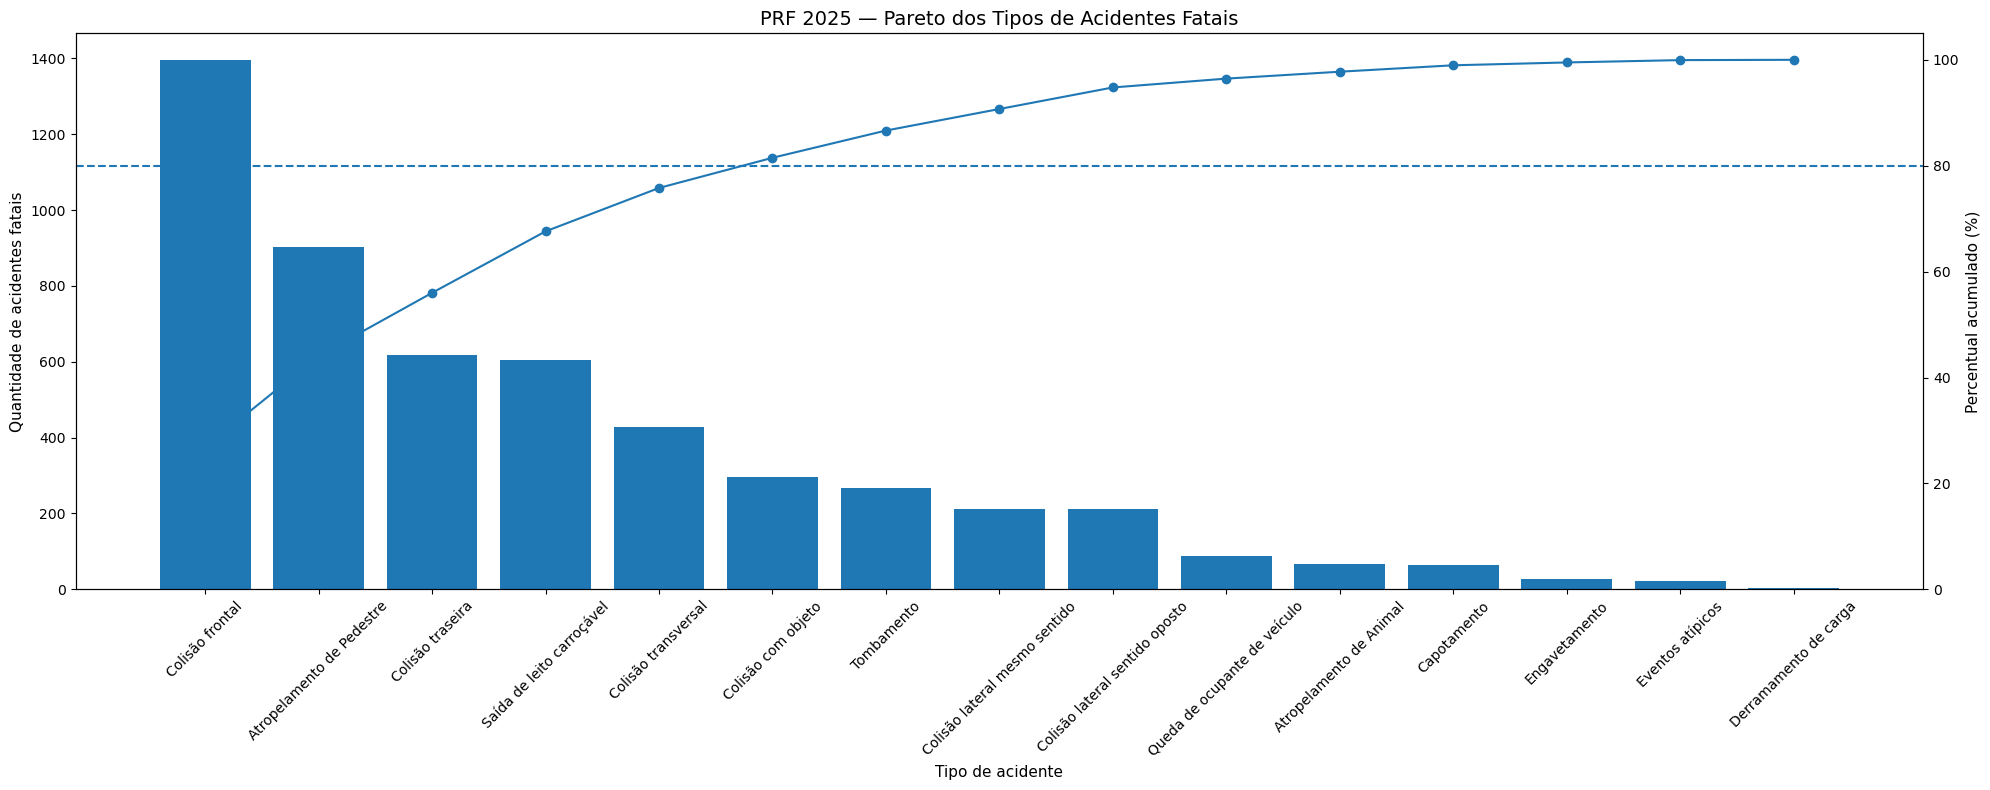

📌 Leitura: os 6 primeiros tipos concentram aproximadamente 81.5% dos acidentes fatais.
O tipo com maior volume fatal é 'Colisão frontal', com 1396 ocorrências fatais.


In [19]:
# Quantidade de acidentes fatais por tipo
fatal = df[df["acidente_fatal"] == 1]
p = fatal["tipo_acidente"].value_counts()
acum = p.cumsum() / p.sum() * 100

fig, ax1 = plt.subplots(figsize=(20, 8))

# Barras: quantidade de acidentes fatais
ax1.bar(p.index, p.values)
ax1.set_xlabel("Tipo de acidente")
ax1.set_ylabel("Quantidade de acidentes fatais")
ax1.tick_params(axis="x", rotation=45)

# Linha: percentual acumulado
ax2 = ax1.twinx()
ax2.plot(p.index, acum.values, marker="o")
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Percentual acumulado (%)")
ax2.set_ylim(0, 105)

plt.title("PRF 2025 — Pareto dos Tipos de Acidentes Fatais")
fig.tight_layout()
plt.savefig(PASTA_GRAFICOS / "14_pareto_tipos_fatais.png", dpi=180, bbox_inches="tight")
plt.show()

qtd_80 = int((acum < 80).sum() + 1)
print(f"📌 Leitura: os {qtd_80} primeiros tipos concentram aproximadamente {acum.iloc[qtd_80-1]:.1f}% dos acidentes fatais.")
print(f"O tipo com maior volume fatal é '{p.index[0]}', com {int(p.iloc[0])} ocorrências fatais.")

# 🌊 Gráfico 15 — Área empilhada de acidentes fatais por tipo de pista

**Mesmo tipo do código original:** `plt.stackplot()`.

### O que ele mostra
Apresenta a evolução mensal dos acidentes fatais divididos por **pista simples, dupla e múltipla**. Como as áreas são empilhadas, a altura total representa o volume mensal de fatais e cada faixa representa a participação de um tipo de pista.

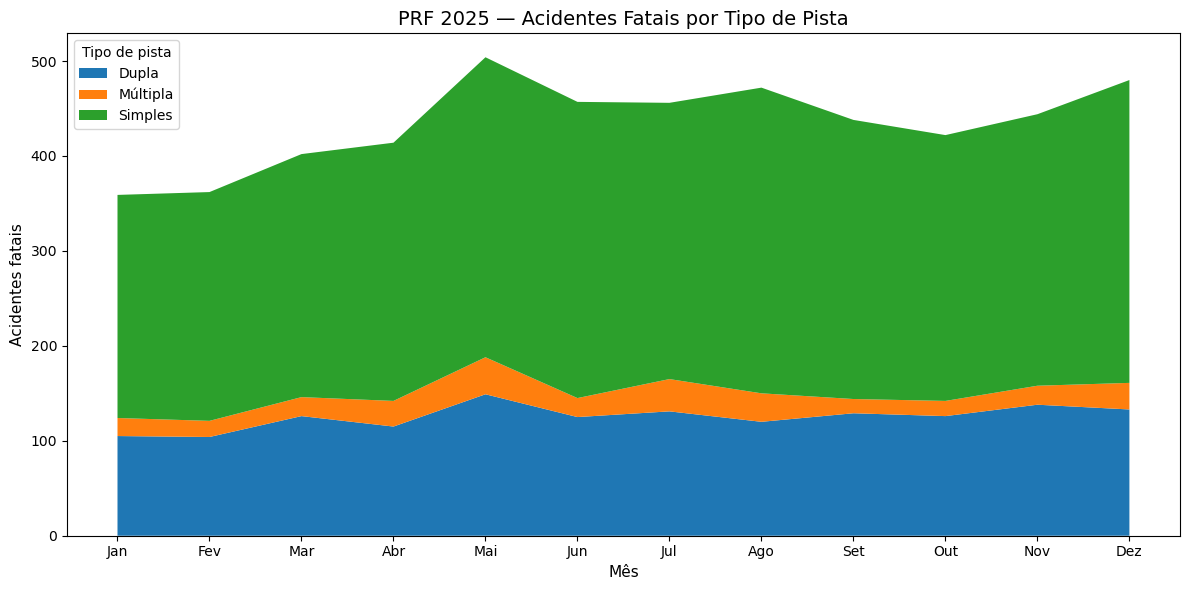

📌 Leitura — total de acidentes fatais por tipo de pista:


,acidentes_fatais
tipo_pista,
Simples,3424
Dupla,1501
Múltipla,285


In [20]:
# Tabela mensal de acidentes fatais por tipo de pista
area = pd.pivot_table(
    df,
    index="mes",
    columns="tipo_pista",
    values="acidente_fatal",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 6))
plt.stackplot(
    area.index,
    *[area[c].values for c in area.columns],
    labels=area.columns
)
plt.title("PRF 2025 — Acidentes Fatais por Tipo de Pista")
plt.legend(title="Tipo de pista", loc="upper left")
plt.xlabel("Mês")
plt.ylabel("Acidentes fatais")
plt.xticks(range(1, 13), [nomes_meses[i] for i in range(1, 13)])
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "15_area_tipo_pista.png", dpi=180, bbox_inches="tight")
plt.show()

totais_pista = area.sum().sort_values(ascending=False)
print("📌 Leitura — total de acidentes fatais por tipo de pista:")
display(totais_pista.to_frame("acidentes_fatais"))

# 🎯 Gráfico 16 — Radar das 3 UFs com mais acidentes fatais

**Mesmo tipo de gráfico do código original:** gráfico polar/radar.

### O que ele mostra
Compara as três UFs com maior volume de acidentes fatais em cinco dimensões:

- Fatais;
- percentual de acidentes fatais (`Taxa_fatal`);
- pessoas envolvidas;
- feridos graves;
- veículos.

As métricas possuem escalas muito diferentes, por isso são **normalizadas de 0 a 10 apenas entre as três UFs selecionadas**, seguindo o código fornecido. O radar serve para comparar perfis, não valores absolutos.

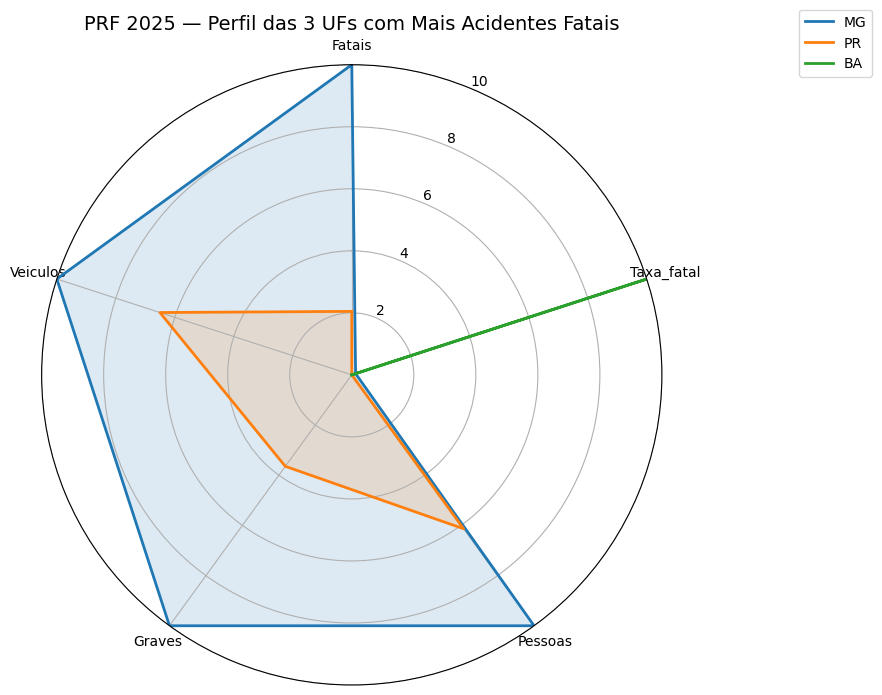

📌 Valores absolutos usados antes da normalização:


,Acidentes,Fatais,Pessoas,Graves,Veiculos,Taxa_fatal
uf,,,,,,
MG,9570,647,25746,2939,19102,6.760711
PR,7630,511,20264,1893,15465,6.697248
BA,4108,476,11568,1293,8699,11.587147



📌 Leitura: o radar compara perfis relativos. Uma UF pode ter menor volume absoluto e, ao mesmo tempo, maior percentual de acidentes fatais.


In [21]:
# Agregação por UF
agg = df.groupby("uf").agg(
    Acidentes=("id", "count"),
    Fatais=("acidente_fatal", "sum"),
    Pessoas=("pessoas", "sum"),
    Graves=("feridos_graves", "sum"),
    Veiculos=("veiculos", "sum")
)

# Percentual de acidentes fatais dentro de cada UF
agg["Taxa_fatal"] = agg["Fatais"] / agg["Acidentes"] * 100

# Seleciona as três UFs com maior número absoluto de acidentes fatais
top = agg.nlargest(3, "Fatais")
metricas = ["Fatais", "Taxa_fatal", "Pessoas", "Graves", "Veiculos"]

# Normalização 0-10 entre as três UFs selecionadas
amplitude = top[metricas].max() - top[metricas].min()
amplitude = amplitude.replace(0, 1)  # evita divisão por zero
norm = (top[metricas] - top[metricas].min()) / amplitude * 10

# Ângulos do radar
angulos = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
angulos += angulos[:1]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(metricas)
ax.set_ylim(0, 10)

for uf_nome in top.index:
    valores = norm.loc[uf_nome].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=2, label=uf_nome)
    ax.fill(angulos, valores, alpha=0.15)

ax.set_title("PRF 2025 — Perfil das 3 UFs com Mais Acidentes Fatais", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "16_radar_top3_ufs.png", dpi=180, bbox_inches="tight")
plt.show()

print("📌 Valores absolutos usados antes da normalização:")
display(top)
print("\n📌 Leitura: o radar compara perfis relativos. Uma UF pode ter menor volume absoluto e, ao mesmo tempo, maior percentual de acidentes fatais.")

# ✅ Conclusões gerais

Os gráficos preservam os **mesmos modelos estatísticos e visuais** do notebook fornecido e foram adaptados para a base consolidada da PRF 2025.

Principais achados da execução:

- A base possui **72.529 acidentes**.
- Foram identificados **5.210 acidentes fatais**, equivalentes a aproximadamente **7,18%** das ocorrências.
- Houve **6.043 mortes** e **89.593 vítimas**, resultando em taxa de letalidade operacional de aproximadamente **6,74%**.
- A maioria dos acidentes fatais registra **uma única morte**, embora existam eventos de múltiplas vítimas fatais.
- **Minas Gerais** lidera o volume absoluto de acidentes fatais entre as UFs.
- **Plena Noite** concentra a maior participação dos acidentes fatais quando observamos somente o conjunto fatal.
- **Maio** apresenta o maior número mensal de acidentes fatais e também o maior percentual mensal em 2025.
- No Pareto, poucos tipos de acidente concentram a maior parte das ocorrências fatais, com destaque para **colisão frontal**.
- Pistas **simples** concentram a maior quantidade de acidentes fatais na comparação por tipo de pista.

> Estes resultados são descritivos. Associação visual ou correlação estatística não prova causalidade.

## 💾 Arquivos gerados

Ao executar o notebook, cada visualização é salva automaticamente na pasta `graficos/` em formato PNG. Assim, os gráficos podem ser reutilizados no README, no GitHub ou em uma apresentação.